## Exploring and Preprocessing Mental Health Data

### Schritt 1: Initialisierung und Laden der Daten
- Importiere die erforderlichen Bibliotheken und lade die Trainings- und Testdatensätze.
- Verarbeite beide Datensätze gleichzeitig, damit das endgültige Modell bei der Vorhersage genau dieselben Merkmalsstrukturen erhält.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load datasets
train_dataset = pd.read_csv("train.csv")
test_dataset = pd.read_csv("test.csv")

display(train_dataset.head())

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [2]:
print(train_dataset['Dietary Habits'].unique())
print(train_dataset['Sleep Duration'].unique())

['Healthy' 'Unhealthy' 'Moderate' 'Yes' 'Pratham' 'BSc' 'Gender' '3'
 'More Healthy' 'Less than Healthy' 'Mihir' '1.0' 'Hormonal' 'Electrician'
 nan 'No Healthy' 'Less Healthy' 'M.Tech' 'Vegas' 'No' 'Male' 'Indoor'
 'Class 12' '2']
['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours'
 'Sleep_Duration' '1-2 hours' '6-8 hours' '4-6 hours' '6-7 hours'
 '10-11 hours' '8-9 hours' '40-45 hours' '9-11 hours' '2-3 hours'
 '3-4 hours' 'Moderate' '55-66 hours' '4-5 hours' '9-6 hours' '1-3 hours'
 'Indore' '45' '1-6 hours' '35-36 hours' '8 hours' 'No' '10-6 hours'
 'than 5 hours' '49 hours' 'Unhealthy' 'Work_Study_Hours' '3-6 hours'
 '45-48 hours' '9-5' 'Pune' '9-5 hours']


### Schritt 2: Feature Engineering & Datenbereinigung
Es gibt mehrere Spalten, die bereinigt und zusammengefasst werden müssen. Um zu vermeiden, denselben Code zweimal zu schreiben (einmal für das Training, einmal für den Test), erstellen wir eine einzige Funktion `preprocess_features`, die die gesamte Logik abdeckt:

1. **Kombinierter Druck:** `Academic Pressure` und `Work Pressure` schließen sich gegenseitig aus => zusammenführen
2. **Kombinierte Zufriedenheit:** Ebenso werden wir `Study Satisfaction` und `Job Satisfaction` zusammenführen.
3. **Studentenstatus:** Umwandlung von `Working Professional or Student` in eine binäre Spalte `is_student`.
4. **Gesundheitsindex:** Zuordnung von `Dietary Habits` und `Sleep Duration` zu numerischen Werten und Zusammenführung zu einem einzigen Index.
5. **Umgang mit fehlenden Werten:** Auffüllen von NaNs in numerischen Spalten (wie CGPA und Alter) und kategorialen Spalten (wie Beruf und Abschluss).
6. **Entfernen unnötiger Daten:** Wir entfernen `Name`, da dieser keinen prädiktiven Wert hat.


In [4]:
def preprocess_features(df):
    df = df.copy()
    
    # 1. Kombinierter Druck
    df['Academic Pressure'] = df['Academic Pressure'].fillna(0)
    df['Work Pressure'] = df['Work Pressure'].fillna(0)
    df['Combined Pressure'] = df['Academic Pressure'] + df['Work Pressure']
    df.drop(['Academic Pressure', 'Work Pressure'], axis=1, inplace=True)
    
    # 2. Kombinierter Zufriedenheit
    df['Study Satisfaction'] = df['Study Satisfaction'].fillna(0)
    df['Job Satisfaction'] = df['Job Satisfaction'].fillna(0)
    df['Combined Satisfaction'] = df['Study Satisfaction'] + df['Job Satisfaction']
    df.drop(['Study Satisfaction', 'Job Satisfaction'], axis=1, inplace=True)
    
    # 3. Studentenstatus
    df['is_student'] = (df['Working Professional or Student'] == 'Student').astype(int)
    df.drop('Working Professional or Student', axis=1, inplace=True)
    
    # 4. Gesundheitsindex
    diet_map = {'Healthy': 3, 'Moderate': 2, 'Unhealthy': 1}
    sleep_map = {'More than 8 hours': 4, '7-8 hours': 3, '5-6 hours': 2, 'Less than 5 hours': 1}
    df['Dietary Habits'] = df['Dietary Habits'].fillna('Moderate') # filled NaN vals with the middle nr from map
    df['Sleep Duration'] = df['Sleep Duration'].fillna('7-8 hours') # same here
    df['Health_Index'] = df['Dietary Habits'].map(diet_map) + df['Sleep Duration'].map(sleep_map)
    df['Health_Index'] = df['Health_Index'].fillna(df['Health_Index'].median())  # ADD THIS
    df.drop(['Dietary Habits', 'Sleep Duration'], axis=1, inplace=True)
    
    # 5. Umgang mit fehlenden Werten
    df['CGPA'] = df['CGPA'].fillna(0)
    df['Age'] = df['Age'].fillna(df['Age'].median())                          # NEW
    df['Work/Study Hours'] = df['Work/Study Hours'].fillna(df['Work/Study Hours'].median())  # NEW
    df['Financial Stress'] = df['Financial Stress'].fillna(0)                 # NEW
    df['Profession'] = df['Profession'].fillna('Unknown')
    df['Degree'] = df['Degree'].fillna('Unknown')
    df['City'] = df['City'].fillna('Unknown')
    df['Gender'] = df['Gender'].fillna('Unknown')                             # NEW
    df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].fillna('Unknown')  # NEW
    df['Family History of Mental Illness'] = df['Family History of Mental Illness'].fillna('Unknown') #NEW
    # 6. Entfernen unnötiger daten (Name)
    df.drop(['Name'], axis=1, inplace=True)
    
    return df

X_train_full = preprocess_features(train_dataset)
X_test = preprocess_features(test_dataset)

y_train = X_train_full['Depression']    # target vector
X_train = X_train_full.drop(['Depression'], axis=1)    # feature matrix

display(X_train.head())

,id,Gender,Age,City,Profession,CGPA,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Combined Pressure,Combined Satisfaction,is_student,Health_Index
0,0,Female,49.0,Ludhiana,Chef,0.00,BHM,No,1.0,2.0,No,5.0,2.0,0,7.0
1,1,Male,26.0,Varanasi,Teacher,0.00,LLB,Yes,7.0,3.0,No,4.0,3.0,0,2.0
2,2,Male,33.0,Visakhapatnam,Unknown,8.97,B.Pharm,Yes,3.0,1.0,No,5.0,2.0,1,5.0
3,3,Male,22.0,Mumbai,Teacher,0.00,BBA,Yes,10.0,1.0,Yes,5.0,1.0,0,3.0
4,4,Female,30.0,Kanpur,Business Analyst,0.00,BBA,Yes,9.0,4.0,Yes,1.0,1.0,0,3.0


### Schritt 3: Kodierung kategorialer Variablen
- Umwandlung der verbleibenden Textspalten (`Gender`, `City`, `Profession`, `Degree`, `Have you ever had suicidal thoughts ?`, `Family History of Mental Illness`) in Zahlen. 
- Dazu werden `ColumnTransformer` und `OneHotEncoder` aus Scikit-Learn verwendet, um dies dynamisch durchzuführen.
- Skalierung der numerischen Merkmale, damit sie auf derselben Skala liegen.

In [5]:
categorical_cols = ['Gender', 'City', 'Profession', 'Degree', 
                    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

numerical_cols = ['Age', 'CGPA', 'Work/Study Hours', 'Financial Stress', 
                  'Combined Pressure', 'Combined Satisfaction', 'is_student', 'Health_Index']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train)

            id  Gender   Age           City         Profession  CGPA  \
0            0  Female  49.0       Ludhiana               Chef  0.00   
1            1    Male  26.0       Varanasi            Teacher  0.00   
2            2    Male  33.0  Visakhapatnam            Unknown  8.97   
3            3    Male  22.0         Mumbai            Teacher  0.00   
4            4  Female  30.0         Kanpur   Business Analyst  0.00   
...        ...     ...   ...            ...                ...   ...   
140695  140695  Female  18.0      Ahmedabad            Unknown  0.00   
140696  140696  Female  41.0      Hyderabad     Content Writer  0.00   
140697  140697  Female  24.0        Kolkata  Marketing Manager  0.00   
140698  140698  Female  49.0       Srinagar            Plumber  0.00   
140699  140699    Male  27.0          Patna            Unknown  9.24   

          Degree Have you ever had suicidal thoughts ?  Work/Study Hours  \
0            BHM                                    No     

In [5]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
CGPA                                     0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Combined Pressure                        0
Combined Satisfaction                    0
is_student                               0
Health_Index                             0
dtype: int64
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
CGPA                                     0
Degree                                   0
Have you ever had suicidal thoughts ?    

## Splitting Training Data 
75% **training** - 25% **test** Data with **cross-validation**
every team member has to have the same split, so that the results from the models are comparable  

In [6]:
from sklearn.model_selection import train_test_split
print(X_train_processed.shape)
print(y_train.shape)
# Everyone uses this exact split
(X_tr, X_val, y_tr, y_val) = train_test_split( X_train_processed, y_train,
                                               test_size = 0.25,
                                               random_state = 42,
                                               stratify = y_train
    
                                                       
)
print(X_tr.shape)
print(y_tr.shape)
print(X_val.shape)
print(y_val.shape)

(140700, 294)
(140700,)
(105525, 294)
(105525,)
(35175, 294)
(35175,)


## KNN
1.create: am creat modelul </br>
2.train: l-am antrenat cu fit.(X_tr, y_tr) </br>
3.predict: folosesc modelul ca sa prezica pe X_val cu .predict() </br>
4.evaluate: vad cat de bine a prezis - cassification_report cu accuracy, precision, recall, F1. </br>

K=3 → accuracy: 0.8162
              precision    recall  f1-score   support

           0       0.84      0.96      0.90     28783
           1       0.48      0.18      0.26      6392

    accuracy                           0.82     35175
   macro avg       0.66      0.57      0.58     35175
weighted avg       0.78      0.82      0.78     35175

K=5 → accuracy: 0.8136
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     28783
           1       0.43      0.08      0.14      6392

    accuracy                           0.81     35175
   macro avg       0.63      0.53      0.52     35175
weighted avg       0.75      0.81      0.76     35175

K=7 → accuracy: 0.8125
              precision    recall  f1-score   support

           0       0.82      0.98      0.90     28783
           1       0.35      0.04      0.06      6392

    accuracy                           0.81     35175
   macro avg       0.58      0.51      0.48     35175
weigh

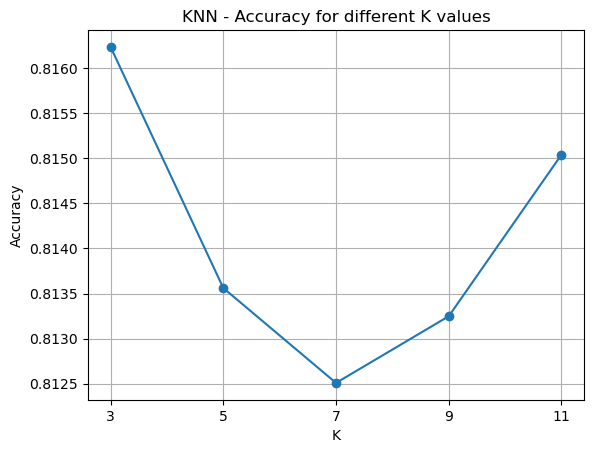

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

k_values = [3, 5, 7, 9, 11]
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(k)
    knn.fit(X_tr, y_tr)
    y_predicted = knn.predict(X_val)
    accuracies.append(accuracy_score(y_val, y_predicted))
    print(f"K={k} → accuracy: {accuracy_score(y_val, y_predicted):.4f}")
    print(classification_report(y_val, y_predicted))

# Plot după buclă
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN - Accuracy for different K values')
plt.xticks(k_values)
plt.grid(True)
plt.show()



## Decision Tree


--- max_depth=3 ---
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     28783
           1       0.82      0.67      0.74      6392

    accuracy                           0.91     35175
   macro avg       0.87      0.82      0.84     35175
weighted avg       0.91      0.91      0.91     35175


--- max_depth=5 ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     28783
           1       0.81      0.76      0.79      6392

    accuracy                           0.92     35175
   macro avg       0.88      0.86      0.87     35175
weighted avg       0.92      0.92      0.92     35175


--- max_depth=7 ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     28783
           1       0.82      0.78      0.80      6392

    accuracy                           0.93     35175
   macro avg       0.88      0.87      0.88     35175
weighted av

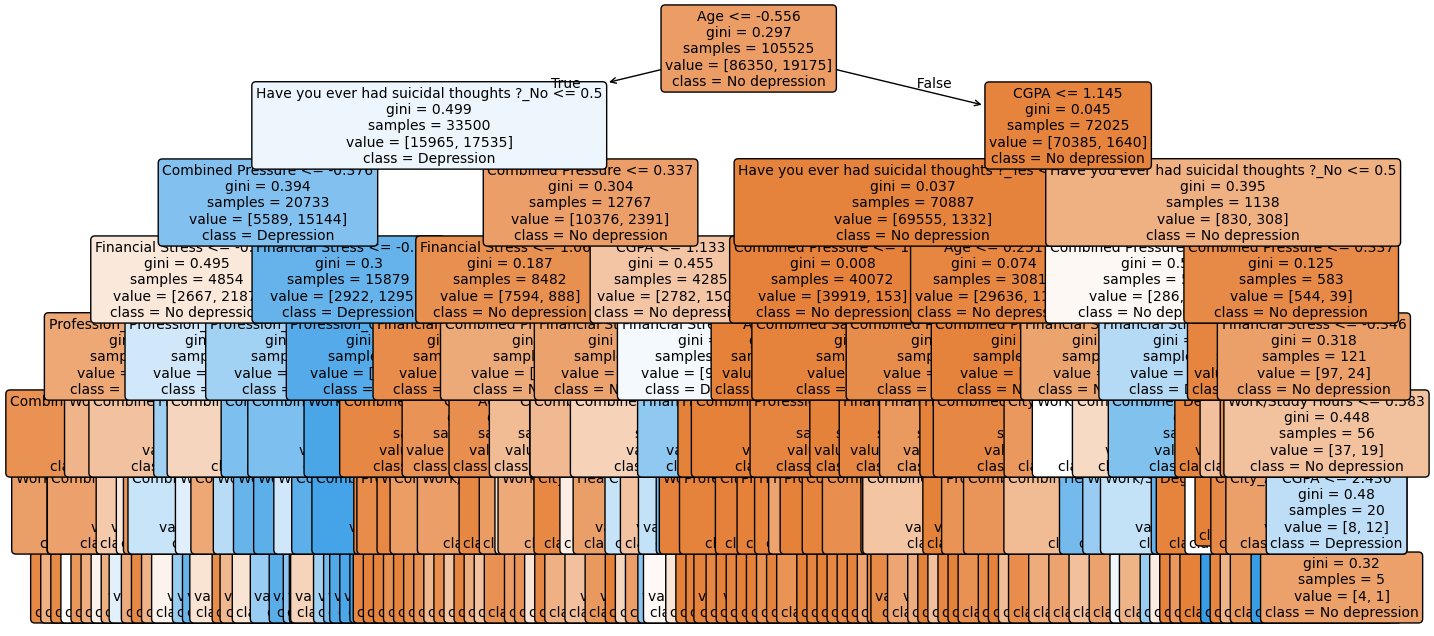

In [8]:
from sklearn.tree import DecisionTreeClassifier
for depth in [3, 5, 7, 10]:
    decision_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    decision_tree.fit(X_tr, y_tr)
    y_predicted = decision_tree.predict(X_val)
    print(f"\n--- max_depth={depth} ---")
    print(classification_report(y_val, y_predicted))

num_cols_names = numerical_cols
cat_cols_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_cols = num_cols_names + cat_cols_names + ['id']

decision_tree_best=DecisionTreeClassifier(max_depth=7, random_state=42)
decision_tree_best.fit(X_tr, y_tr)

from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8)) 
tree.plot_tree(decision_tree_best,
    feature_names=all_cols,  
    class_names=["No depression", "Depression"],       
    filled=True,                              
    rounded=True,                             
    fontsize=10)
plt.show()

## RandomForestClassifier with default params:

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report 
# Model 1
rf = RandomForestClassifier()
rf.fit(X_tr, y_tr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Accuracy**

In [8]:
rf.score(X_val, y_val)

0.9340156361051883

**comparing the predicted values from test set to the actual target values**

In [9]:
y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     28783
           1       0.85      0.78      0.81      6392

    accuracy                           0.93     35175
   macro avg       0.90      0.87      0.89     35175
weighted avg       0.93      0.93      0.93     35175



## Balancing Random Forest Classifier with weights
cause I can tweak directly in tne Classifier param list, instead of using oversampling with SMOTE
**main reason** 
the recall score for classifying depression as true is only 0.77 which means there are 0.33 false negatives, that is more valuable to get right than the negatives.

In [10]:
rf_balanced = RandomForestClassifier(class_weight = 'balanced')
rf_balanced.fit(X_tr, y_tr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
rf_balanced.score(X_val, y_val)

0.9323667377398721

In [12]:
y_pred_balanced = rf_balanced.predict(X_val)
print(classification_report(y_val, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     28783
           1       0.85      0.76      0.80      6392

    accuracy                           0.93     35175
   macro avg       0.90      0.87      0.88     35175
weighted avg       0.93      0.93      0.93     35175



## XGBoost Classifier 

In [14]:
from xgboost import XGBClassifier

In [16]:
!pip install xgboost


In [15]:
xgb = XGBClassifier(random_state = 42)
xgb.fit(X_tr, y_tr)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [16]:
xgb.score(X_val, y_val)

0.9364321250888415

In [17]:
y_pred_xgb = xgb.predict(X_val)
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     28783
           1       0.83      0.81      0.82      6392

    accuracy                           0.94     35175
   macro avg       0.90      0.89      0.89     35175
weighted avg       0.94      0.94      0.94     35175



# Hyperparameter Tuning on XGBClassifier


In [18]:
from sklearn.model_selection import RandomizedSearchCV

In [19]:
xgb_tuned = XGBClassifier()
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [3, 5 , 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample' : [0.7, 0.8, 1.0],
    'scale_pos_weight' : [1, 3, 4.5]
}
xgb_search = RandomizedSearchCV(
    xgb_tuned,
    param_grid,
    cv = 5,
    scoring = 'f1',
    n_iter = 20, 
    n_jobs = -1,
    random_state = 42
)


In [20]:
xgb_search.fit(X_tr, y_tr)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'scale_pos_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [21]:
xgb_search.best_params_


{'subsample': 0.7,
 'scale_pos_weight': 1,
 'n_estimators': 300,
 'max_depth': 5,
 'learning_rate': 0.05}

In [22]:
xgb_search.best_score_ #best f1 score 

np.float64(0.8301972753936591)

In [23]:
xgb_search.best_estimator_.score(X_val, y_val) #accuracy

0.9376261549395878

In [24]:
y_pred_xgb_tuned = xgb_search.best_estimator_.predict(X_val)
print(classification_report(y_val, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     28783
           1       0.84      0.82      0.83      6392

    accuracy                           0.94     35175
   macro avg       0.90      0.89      0.89     35175
weighted avg       0.94      0.94      0.94     35175



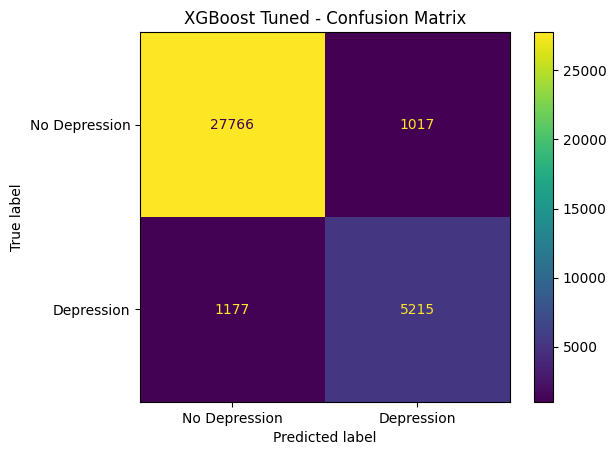

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_xgb_tuned, display_labels=['No Depression', 'Depression'])
plt.title('XGBoost Tuned - Confusion Matrix')
plt.show()


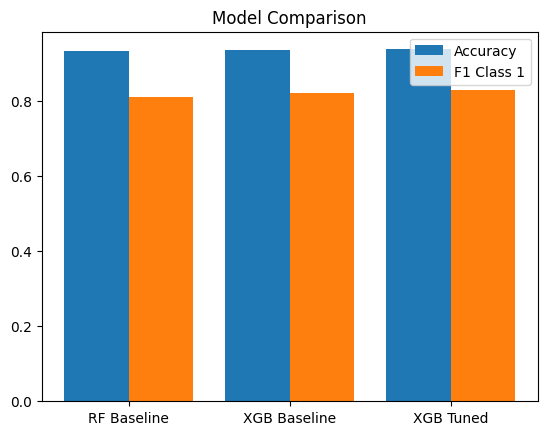

In [31]:
models = ['RF Baseline', 'XGB Baseline', 'XGB Tuned']
accuracies = [rf.score(X_val, y_val), xgb.score(X_val, y_val), xgb_search.best_estimator_.score(X_val, y_val)]
f1_scores = [0.81, 0.82, 0.83]  # class 1 F1 from reports

x = np.arange(len(models))
plt.bar(x - 0.2, accuracies, 0.4, label='Accuracy')
plt.bar(x + 0.2, f1_scores, 0.4, label='F1 Class 1')
plt.xticks(x, models)
plt.legend()
plt.title('Model Comparison')
plt.show()


# NAIVE BAYES


In [ ]:
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

print("start")

# the gaussian naive bayes assumes a normal dstribution of the features
# hence, we make the data more gaussian-like
# Initialize and fit the PowerTransformer
pt = PowerTransformer(standardize=True) # Standard Scaling already included
X_tr_transformed = pt.fit_transform(X_tr)
X_val_transformed = pt.transform(X_val)

# Train the model
nb_classifier = GaussianNB()
nb_classifier.fit(X_tr_transformed, y_tr)

# Make predictions on evaluation set (25% of training set)
y_pred_nb = nb_classifier.predict(X_val_transformed)

# Check accuracy
accuracy = accuracy_score(y_val, y_pred_nb)
print(f"NB Accuracy: {accuracy:.4f}")

print("end")

In [ ]:
#verify class distribution - to justify the low score in accuracy
print(y_train.value_counts(normalize=True))

#show class distribution
y_train.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print("\n=== GaussianNB ===")
print(confusion_matrix(y_val, y_pred_nb))
print(classification_report(y_val, y_pred_nb))

# Confusion Matrix plot
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_nb)
plt.title("GaussianNB Confusion Matrix")
plt.show()

# SUPPORT VECTOR MACHINES

In [ ]:
print("printing")
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC 

# class_weight (penalize more wrong predictions on the class that has less examples)
print("starting svm...")
svm = LinearSVC (class_weight = 'balanced', max_iter = 10000, random_state = 42)
svm.fit(X_tr, y_tr)

print("predicting svm...")
y_pred_svm = svm.predict(X_val_transformed)

# evaluate the model
print("\nLinearSVM Accuracy:", accuracy_score(y_val, y_pred_svm))

print("printing visualisations...")
# print graphical visualisation
print("\n=== SVM ===")
print(confusion_matrix(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()

# Hyperparameter Tuning on SVM


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.svm import LinearSVC

param_dist = {
    'C': loguniform(0.001, 1000)  # continuous distribution
}

rand_search = RandomizedSearchCV(
    LinearSVC(class_weight='balanced', max_iter=10000, random_state=42),
    param_distributions=param_dist,
    n_iter=20,       # try 20 random values
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_tr_transformed, y_tr)
print("Best C:", rand_search.best_params_)
print("Best CV F1:", rand_search.best_score_)

In [ ]:
# Predict on validation set with tuned model
y_pred_svm_tuned = rand_search.best_estimator_.predict(X_val_transformed)

# Compute accuracy
accuracy_tuned = accuracy_score(y_val, y_pred_svm_tuned)
print(f"Tuned LinearSVC Accuracy: {accuracy_tuned:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score


# gaussian NB metrics
nb_accuracy = accuracy_score(y_val, y_pred_nb)
nb_f1_class1 = f1_score(y_val, y_pred_nb, pos_label=1)


# LinearSVC metrics
svm_accuracy = accuracy_score(y_val, y_pred_svm)
svm_f1_class1 = f1_score(y_val, y_pred_svm, pos_label=1)

# Model comparison plot
models = ['Gaussian NB', 'Linear SVM']
accuracies = [nb_accuracy, svm_accuracy]
f1_scores = [nb_f1_class1, svm_f1_class1]

x = np.arange(len(models))
plt.figure(figsize=(8,5))
plt.bar(x - 0.2, accuracies, 0.4, label='Accuracy')
plt.bar(x + 0.2, f1_scores, 0.4, label='F1 Class 1')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Comparison: GaussianNB vs LinearSVC')
plt.legend()
plt.show()

In [32]:
X_test_final = preprocessor.transform(X_test)

# Initialize and Fit
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_processed, y_train)

# Predict on test set
rf_predictions = rf_model.predict(X_test_final)

In [33]:
# Initialize and Fit
xgb_model = XGBClassifier(
    n_estimators=300, 
    max_depth=5, 
    learning_rate=0.1, 
    scale_pos_weight=3,
    random_state=42
)
xgb_model.fit(X_train_processed, y_train)

# Predict on test set
xgb_predictions = xgb_model.predict(X_test_final)

In [ ]:
results = pd.DataFrame({
    'id': test_dataset['id'],
    'RF_Prediction': rf_predictions,
    'XGB_Prediction': xgb_predictions
})

results.to_csv('model_predictions.csv', index=False)

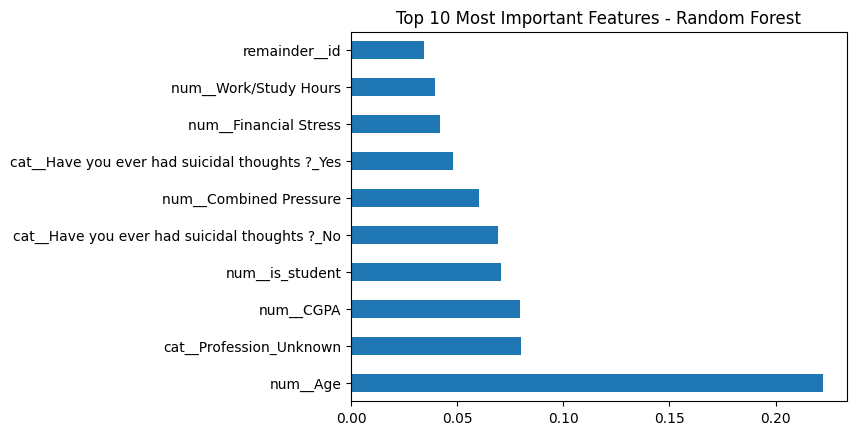

In [36]:
import matplotlib.pyplot as plt

# 1. Get the scores from your
# trained model
importances = rf_model.feature_importances_

# 2. Get the feature names from your preprocessor
# This is important because OneHotEncoding creates many new columns
feature_names = preprocessor.get_feature_names_out()

# 3. Plot the top 10 most important features
feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Important Features - Random Forest")
plt.show()